In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
images = [os.path.join('data/images',f) for f in os.listdir('data/images') if f.endswith(('.jpg'))]

In [ ]:
len(images)

In [ ]:
imgs = [plt.imread(i) for i in images]

In [ ]:
imgs = [i for i in imgs if i.shape[-1]==3]
shapes = ([np.array(img.shape) for img in (imgs)])

In [ ]:
len(imgs)

In [ ]:
shapes

In [ ]:
np.argmin(W)

In [ ]:
plt.imshow(imgs[5929])

In [ ]:

d

In [ ]:
d.resize((224,224),resample=Image.LANCZOS)

In [ ]:
from PIL.ImageOps import solarize,posterize,autocontrast,equalize

In [ ]:
import random
e = 


In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from PIL.ImageOps import autocontrast, posterize
from PIL.ImageTransform import AffineTransform

# pick random image
d = Image.fromarray(random.choice(imgs))

from PIL import ImageEnhance

def mild_color(img):
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.9, 1.1))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.9, 1.1))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.9, 1.1))
    return img

def slight_affine_coeffs(eps=0.02, translate=2):
    return (
        1 + random.uniform(-eps, eps),  # a
        random.uniform(-eps, eps),      # b
        random.uniform(-translate, translate),  # c
        random.uniform(-eps, eps),      # d
        1 + random.uniform(-eps, eps),  # e
        random.uniform(-translate, translate)   # f
    )

def augment(img):
    coeff = slight_affine_coeffs()
    t = AffineTransform(coeff)
    
    e = t.transform(img.size, img)
    e = e.resize((224, 224), Image.LANCZOS)
    
    e = mild_color(e)  # replace harsh ops
    
    return e

# generate 5 augmented images
augmented = [augment(d) for _ in range(5)]

# plot
plt.figure(figsize=(12, 4))

# original
plt.subplot(1, 6, 1)
plt.imshow(d)
plt.title("Original")
plt.axis("off")

# augmented
for i, img in enumerate(augmented):
    plt.subplot(1, 6, i + 2)
    plt.imshow(img)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from data.pets_dataset import OxfordIIITPetDataset_localize



In [ ]:
d

In [ ]:
import os
import xml.etree.ElementTree as ET

with open('data/annotations/trainval.txt') as f:
    content = f.read().split('\n')
# split the train val from the list above and the dataset takes this list as input 


# store (image_path, class_id, seg_path, species, breed_id)
data = []

for c in content:
    name,c_id,sp,brd = c.split(' ')
    class_id = int(c_id)
    species  = int(sp)
    breed_id = int(brd)

    img_path = os.path.join('images',name+'.jpg')
    seg_path = os.path.join('annotations/trimaps',name+'.png')

    data.append((img_path, class_id, seg_path, species, breed_id))

In [ ]:
ET.parse("data/annotations/xmls/Abyssinian_1.xml")

In [ ]:
not_exist = []
with open('data/annotations/train.txt') as f:
    content_test = f.read().split('\n')
for c in content_test:

    name,c_id,sp,brd = c.split(' ')

    if not os.path.exists(os.path.join('data/annotations/xmls', name+'.xml')):
        not_exist.append(name)


In [ ]:
len(not_exist)

In [ ]:
from data.pets_dataset import *
import numpy as np


In [ ]:
with open('data/annotations/trainval.txt') as f:
    contents = f.read().split('\n')

np.random.shuffle(contents)
split_idx = int(len(contents)*0.8)
train_data = contents[:split_idx]
val_data = contents[split_idx:]

In [ ]:
train_dataset = OxfordIIITPetDataset_localize(train_data, transform=Image_transform_classify)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_same_image(dataset, index=0, num_samples=8, cols=4):
    """
    Args:
        dataset     : returns (image, bbox)
        index       : index of the image to repeat
        num_samples : how many times to show (with augmentation)
        cols        : grid columns
    """
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(num_samples):
        # Always fetch the SAME image index
        image, bbox = dataset[index]

        ax = axes[i]

        img_show = np.transpose(image, (1, 2, 0))
        img_show = img_show * std + mean
        img_show = np.clip(img_show, 0, 1)

        ax.imshow(img_show)

        xc, yc, w, h = bbox
        x0 = xc - w / 2
        y0 = yc - h / 2

        rect = patches.Rectangle(
            (x0, y0), w, h,
            linewidth=2,
            edgecolor='lime',
            facecolor='none'
        )
        ax.add_patch(rect)

        ax.set_title(f'Augmented {i}', fontsize=10)
        ax.axis('off')

    # Hide unused axes
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Same Image Augmentations', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


# Call it
visualize_same_image(train_dataset, index=np.random.choice(np.arange(0,len(train_dataset))), num_samples=8, cols=4)

In [ ]:
from models.localization import *

In [ ]:
model = VGG11Localizer(encoder_init='checkpoints/best_classification.pth')

In [ ]:
train_dataset = OxfordIIITPetDataset_Segmentation(train_data, Image_transform_classify)

In [ ]:
img,seg = train_dataset[0]

In [ ]:
plt.imshow(seg)
plt.colorbar()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_segmentation_dataset(dataset, num_samples=9, cols=3):
    """
    Args:
        dataset: returns (image, trimap) where
                 image  = tensor [3, 224, 224] normalized
                 trimap = tensor [224, 224] with values 0/1/2
    """
    # Color map for trimap classes
    # 0 = foreground, 1 = background, 2 = boundary
    color_map = np.array([
        [0,   255, 0  ],   # 0: foreground  → green
        [0,   0,   255],   # 1: background  → blue
        [255, 0,   0  ],   # 2: boundary    → red
    ], dtype=np.uint8)

    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols, figsize=(5 * cols, 4 * rows * 2))

    for i in range(num_samples):
        image, trimap = dataset[i]

        # Denormalize image
        img_show = np.transpose(image.numpy(), (1, 2, 0))  # [H, W, 3]
        img_show = img_show 
        img_show = np.clip(img_show, 0, 1)

        # Convert trimap to RGB color map
        trimap_np = trimap.numpy().astype(np.int32)        # [H, W]
        trimap_np[trimap==255.] = 2
        trimap_rgb = color_map[trimap_np]                  # [H, W, 3]

        row = (i // cols) * 2
        col =  i  % cols

        # Top row: image
        axes[row][col].imshow(img_show)
        axes[row][col].set_title(f'Sample {i} — Image', fontsize=9)
        axes[row][col].axis('off')

        # Bottom row: trimap mask
        axes[row + 1][col].imshow(trimap_rgb)
        axes[row + 1][col].set_title(f'Sample {i} — Trimap', fontsize=9)
        axes[row + 1][col].axis('off')

    # Hide unused axes
    for i in range(num_samples, rows * cols):
        row = (i // cols) * 2
        col =  i  % cols
        axes[row][col].axis('off')
        axes[row + 1][col].axis('off')

    # Legend
    legend_elements = [
        patches.Patch(facecolor='green', label='Foreground (0)'),
        patches.Patch(facecolor='blue',  label='Background (1)'),
        patches.Patch(facecolor='red',   label='Boundary (2)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Segmentation Dataset Visualization', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

visualize_segmentation_dataset(train_dataset, num_samples=9, cols=3)

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset,32,True)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
for img,class_id in train_dataloader:
    a = img
    b = class_id
    break

In [ ]:
b.shape

In [ ]:
import random
from PIL.ImageTransform import AffineTransform

In [ ]:
eps = 0.02 ; translate = 2
affine_coeffs = (
    1 + random.uniform(-eps, eps),  # a
    random.uniform(-eps, eps),      # b
    random.uniform(-translate, translate),  # c
    random.uniform(-eps, eps),      # d
    1 + random.uniform(-eps, eps),  # e
    random.uniform(-translate, translate)   # f
)


t = AffineTransform(affine_coeffs)

In [ ]:
t.data

In [ ]:
from losses.iou_loss import IoULoss

Loss = IoULoss()

In [ ]:
import torch

pred_box = torch.rand((32,4))*224


In [ ]:
Loss.forward(pred_box, b)

# Inference 

In [35]:
import torch 
from models.classification import VGG11Classifier
from models.localization import VGG11Localizer
from models.segmentation import VGG11UNet

model = VGG11Classifier()

In [2]:
pretrained = torch.load('checkpoints/best_classification.pth')

In [3]:
import numpy as np
with open('data/annotations/trainval.txt') as f:
    contents = f.read().split('\n')

np.random.shuffle(contents)
split_idx = int(len(contents)*0.8)
train_data = contents[:split_idx]
val_data = contents[split_idx:]

In [4]:
model.load_state_dict(pretrained)

<All keys matched successfully>

In [5]:
from data.pets_dataset import *

with open('data/annotations/test.txt') as f:
    contents = f.read().split('\n')

test_data = contents
test_dataset = OxfordIIITPetDataset_classify(test_data)
# train_data = OxfordIIITPetDataset_Segmentation(train_data)


In [10]:
from torch.utils.data import DataLoader

test_dataloader = DataLoader(test_dataset, 40) 
train_dataloader = DataLoader(train_data, 24)

In [11]:
from train import val_epoch_classification
from losses.iou_loss import Localize_loss
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = torch.nn.CrossEntropyLoss()
val_epoch_classification(model, test_dataloader, criterion, device)

(1.0155830924112617, 0.7176342606544495, 0.7174708043139788)

In [52]:
import PIL.Image as Image
from data.pets_dataset import preprocess_img
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
img = Image.open('private_test/4.jpeg')
img = preprocess_img(img)
img_tensor = torch.tensor(img).unsqueeze(0).to(device)

In [53]:
import numpy as np

In [54]:
img_tensor.shape
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

In [55]:
loc_model = VGG11Localizer()
pretrained = torch.load('checkpoints/best_localization.pth')
loc_model.load_state_dict(pretrained)
loc_model.to(device)
loc_model.eval()
seg_pred = loc_model.forward(img_tensor)

VGG11 encoder not initialized with Pretrained model.


In [56]:
seg_pred.shape

torch.Size([1, 4])

In [57]:
import matplotlib.pyplot as plt

In [58]:
import matplotlib.patches as patches

/tmp/ipykernel_218458/706558668.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image = np.array(img_tensor.cpu())


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

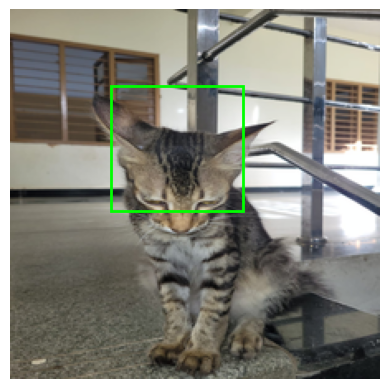

In [59]:
axes = plt.subplot()
image = np.array(img_tensor.cpu())
img_show = np.transpose(image[0], (1, 2, 0))
img_show = img_show * std + mean
img_show = np.clip(img_show, 0, 1)

plt.imshow(img_show)

xc, yc, w, h = seg_pred.detach().cpu().T
x0 = xc - w / 2
y0 = yc - h / 2

rect = patches.Rectangle(
    (x0, y0), w, h,
    linewidth=2,
    edgecolor='lime',
    facecolor='none'
)
axes.add_patch(rect)

# plt.set_title(f'Augmented {i}', fontsize=10)
plt.axis('off')

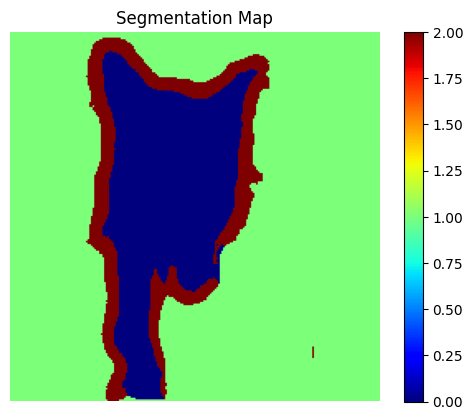

In [21]:
import torch
import matplotlib.pyplot as plt

pred = seg_pred.squeeze(0)
seg_map = torch.argmax(pred, dim=0).cpu().numpy()
plt.imshow(seg_map, cmap='jet')
plt.colorbar()
plt.title("Segmentation Map")
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.288818357065736e-08..1.0000000236034394].


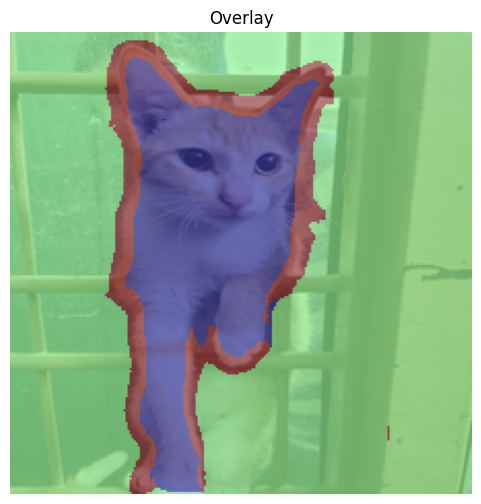

In [22]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image = np.transpose(img, (1, 2, 0))
image = image*std + mean
plt.figure(figsize=(6,6))
plt.imshow(image, alpha=0.7)
plt.imshow(seg_map, cmap='jet', alpha=0.5)
plt.title("Overlay")
plt.axis('off')
plt.show()

In [ ]:
classify_model = VGG11Classifier()
pretrained_classify = torch.load('checkpoints/best_classification.pth')
classify_model.load_state_dict(pretrained_classify)
classify_model = classify_model.to(device).eval()


In [ ]:
pred_class = (classify_model.forward(img_tensor))

In [ ]:
pred_class

In [ ]:
torch.argmax(pred_class)

# Inside blackbox

In [3]:
from models.classification import VGG11Classifier
import torch
import matplotlib.pyplot as plt
model = VGG11Classifier()
pretrained = torch.load('checkpoints/best_classification_gap.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(pretrained)
model = model.to(device)

In [4]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

In [6]:
model.encoder.conv_1.register_forward_hook(get_activation("first_conv"))
model.encoder.conv_5[6].register_forward_hook(get_activation("last_conv"))

In [15]:
from PIL import Image
from data.pets_dataset import preprocess_img


img = Image.open("data/images/american_bulldog_61.jpg").convert("RGB")
input_tensor = torch.tensor(preprocess_img(img)).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    _ = model(input_tensor)

In [16]:
import matplotlib.pyplot as plt

def plot_feature_maps(feature_maps, num_maps=8, title=""):
    feature_maps = feature_maps.squeeze(0)

    plt.figure(figsize=(12, 6))
    for i in range(min(num_maps, feature_maps.shape[0])):
        plt.subplot(2, num_maps//2, i+1)

        fm = feature_maps[i].cpu()
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-5)

        plt.imshow(fm, cmap='viridis')
        plt.axis('off')

    plt.suptitle(title)
    plt.show()

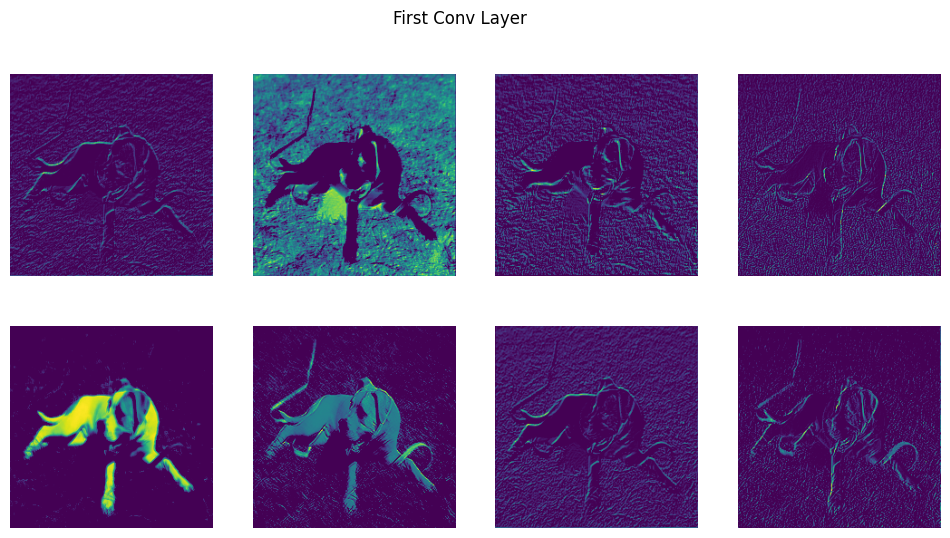

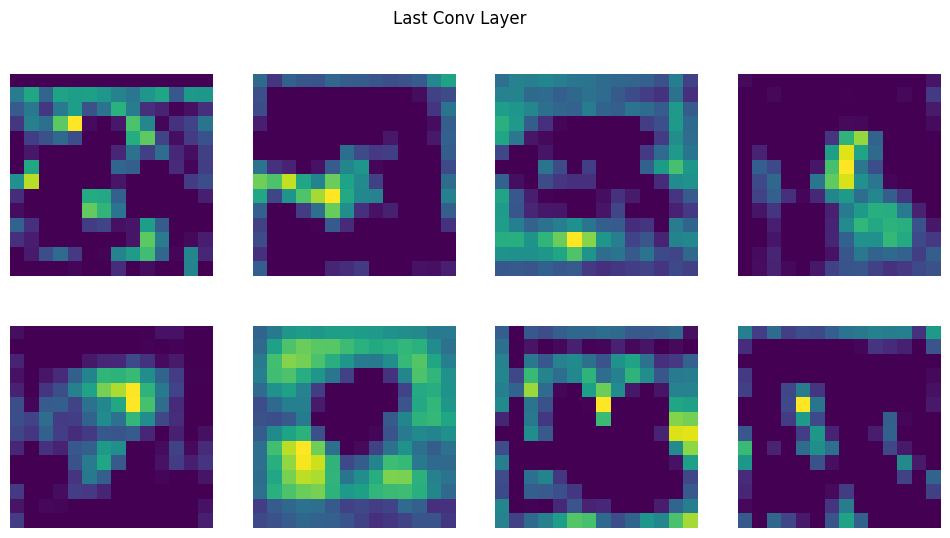

In [19]:
plot_feature_maps(activations["first_conv"], title="First Conv Layer")
plot_feature_maps(activations["last_conv"], title="Last Conv Layer")

In [20]:
import torch
import numpy as np

def feature_maps_to_grid(feature_maps, num_maps=16):
    fmap = feature_maps.squeeze(0)  # [C, H, W]
    fmap = fmap[:num_maps]

    # Normalize each feature map
    fmap_norm = []
    for i in range(fmap.shape[0]):
        fm = fmap[i]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-5)
        fmap_norm.append(fm.cpu().numpy())

    # Convert to numpy
    fmap_norm = np.array(fmap_norm)  # [N, H, W]

    # Grid size (e.g., 4x4 for 16 maps)
    n = int(np.ceil(np.sqrt(len(fmap_norm))))
    h, w = fmap_norm.shape[1], fmap_norm.shape[2]

    grid = np.zeros((n*h, n*w))

    for idx, fm in enumerate(fmap_norm):
        i = idx // n
        j = idx % n
        grid[i*h:(i+1)*h, j*w:(j+1)*w] = fm

    return grid

In [21]:
import wandb

wandb.init(project="cnn-feature-visualization")

def log_feature_maps(input_img, activations):
    
    # First conv
    first_grid = feature_maps_to_grid(activations["first_conv"])
    
    # Last conv
    last_grid = feature_maps_to_grid(activations["last_conv"])

    wandb.log({
        "Input Image": wandb.Image(input_img),
        "First Conv Features": wandb.Image(first_grid, caption="Edges & textures"),
        "Last Conv Features": wandb.Image(last_grid, caption="Semantic features")
    })

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/mk009/.netrc.
wandb: Currently logged in as: ae21b036 (DA6401_JM2026) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [22]:
log_feature_maps(img, activations)

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [39]:
from models.classification import VGG11Classifier
from models.localization import VGG11Localizer
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classify = VGG11Classifier()
localize = VGG11Localizer()
pretrained_cl = torch.load('checkpoints/best_classification_gap.pth')
pretrained_lo = torch.load('checkpoints/best_localization.pth')
classify.load_state_dict(pretrained_cl); localize.load_state_dict(pretrained_lo)
classify = classify.to(device) ; localize = localize.to(device)


from data.pets_dataset import *

with open('data/annotations/trainval.txt') as f:
    contents = f.read().split('\n')
test_data = []
for l in contents:
    name, c_id, sp, brd = l.split(' ')
    xml_path = os.path.join('data/annotations/xmls', name + '.xml')
    if not os.path.exists(xml_path):
        continue

    else:
        test_data.append(l)
# test_data = contents
test_dataset_cl = OxfordIIITPetDataset_classify(test_data)
test_dataset_lo = OxfordIIITPetDataset_localize(test_data)


VGG11 encoder not initialized with Pretrained model.


In [4]:
def xywh_to_xyxy(box):
    xc, yc, w, h = box

    x1 = xc - w / 2
    y1 = yc - h / 2
    x2 = xc + w / 2
    y2 = yc + h / 2

    return [x1, y1, x2, y2]

In [41]:
len(test_dataset_cl)

3671

In [49]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from losses.iou_loss import IoULoss
results = []
l = IoULoss()
classify.eval()
localize.eval()

for i in range(len(test_dataset_lo)//10):
    
    image_cl, _ = test_dataset_cl[i]
    image_lo, gt_box = test_dataset_lo[i]

    image = torch.tensor(image_cl).unsqueeze(0).to(device)

    # ---- Classification ----
    with torch.no_grad():
        logits = classify(image)
        probs = F.softmax(logits, dim=1)
        confidence = probs.max().item()

    # ---- Localization ----
    with torch.no_grad():
        pred_box = localize(image)
        # print(pred_box)
        gt_box = torch.tensor(gt_box).unsqueeze(0).to(device)



    # ---- IoU ----
    iou = l(gt_box, pred_box)

    results.append({
        "idx": i,
        "image": image_cl,
        "gt_box": gt_box,
        "pred_box": pred_box,
        "confidence": confidence,
        "iou": 1-iou
    })

In [57]:
# Define failure: high confidence + low IoU
failures = [r for r in results if r["confidence"] > 0.6 and r["iou"] < 0.6]

# Sort: highest confidence, lowest IoU
failures = sorted(failures, key=lambda x: -(x["confidence"]-x["iou"]))

top5 = sorted(results, key=lambda x: (x["iou"], -x["confidence"]))[:5]

In [35]:
img1,_ = test_dataset_cl[0]
img2,_ = test_dataset_lo[0]

In [26]:
len(failures)

294

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
def show_failure_grid(samples, cols=5):
    rows = int(np.ceil(len(samples) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))

    # Handle case when rows=1
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, sample in enumerate(samples):
        r = i // cols
        c = i % cols

        ax = axes[r, c]

        img = np.transpose(sample["image"],(1, 2, 0))*std+mean
        gt = sample["gt_box"].squeeze(0).cpu().numpy()
        pred = sample["pred_box"].squeeze(0).cpu().numpy()

        ax.imshow(img)
        # print(gt.shape)
        # Ground Truth (Green)
        rect_gt = patches.Rectangle(
            (gt[0] - gt[2]/2, gt[1] - gt[3]/2),  # (x1, y1)
            gt[2],  # width
            gt[3],  # height
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )

        # Prediction (Red)
        rect_pred = patches.Rectangle(
            (pred[0] - pred[2]/2, pred[1] - pred[3]/2),  # (x1, y1)
            pred[2],  # width
            pred[3],  # height
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect_gt)
        ax.add_patch(rect_pred)

        ax.set_title(f"Conf: {sample['confidence']:.2f}\nIoU: {sample['iou']:.2f}")
        ax.axis('off')

    # Hide unused subplots
    for j in range(i+1, rows*cols):
        r = j // cols
        c = j % cols
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.288818357065736e-08..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.288818357065736e-08..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.288818357065736e-08..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.288818357065736e-08..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.288818357065736e-08..1.0000000236034394].


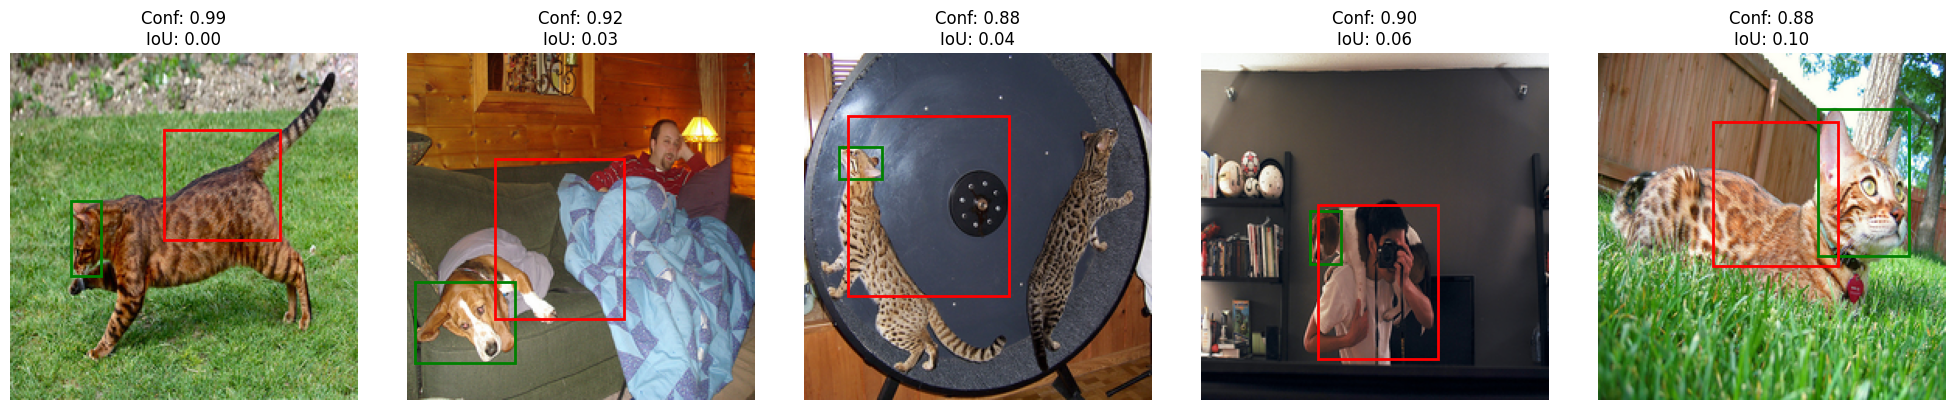

In [58]:
show_failure_grid(failures[:5], cols=5)

In [69]:
import wandb
wandb.init()

In [66]:
def xywh_to_xyxy_norm(box, H, W):
    xc, yc, w, h = box

    x1 = (xc - w/2) / W
    y1 = (yc - h/2) / H
    x2 = (xc + w/2) / W
    y2 = (yc + h/2) / H

    return {
        "minX": float(x1),
        "minY": float(y1),
        "maxX": float(x2),
        "maxY": float(y2),
    }

In [61]:
def log_samples_to_wandb(samples):
    for i, sample in enumerate(samples):

        # ---- Image ----
        img = np.transpose(sample["image"], (1, 2, 0))
        img = img * std + mean
        img = np.clip(img, 0, 1)

        H, W = img.shape[:2]

        # ---- Boxes ----
        gt = sample["gt_box"].squeeze(0).cpu().numpy()
        pred = sample["pred_box"].squeeze(0).cpu().numpy()

        gt_box = xywh_to_xyxy_norm(gt, H, W)
        pred_box = xywh_to_xyxy_norm(pred, H, W)

        boxes = {
            "ground_truth": {
                "box_data": [{
                    "position": gt_box,
                    "class_id": 0,
                    "box_caption": "GT",
                }],
                "class_labels": {0: "Ground Truth"}
            },
            "predictions": {
                "box_data": [{
                    "position": pred_box,
                    "class_id": 1,
                    "box_caption": f"Pred ({sample['confidence']:.2f})",
                    "scores": {"confidence": sample["confidence"]}
                }],
                "class_labels": {1: "Prediction"}
            }
        }

        # ---- Log ----
        wandb.log({
            f"sample_{i}": wandb.Image(
                img,
                boxes=boxes,
                caption=f"Conf: {sample['confidence']:.2f}, IoU: {sample['iou']:.2f}"
            )
        })

In [62]:
log_samples_to_wandb(failures[:10])  

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [70]:
table = wandb.Table(columns=["Image", "Confidence", "IoU"])

for sample in failures[:10]:
    img = np.transpose(sample["image"], (1, 2, 0))
    img = np.clip(img * std + mean, 0, 1)

    H, W = img.shape[:2]

    gt = sample["gt_box"].squeeze(0).cpu().numpy()
    pred = sample["pred_box"].squeeze(0).cpu().numpy()

    gt_box = xywh_to_xyxy_norm(gt, H, W)
    pred_box = xywh_to_xyxy_norm(pred, H, W)

    boxes = {
        "ground_truth": {
            "box_data": [{
                "position": gt_box,
                "class_id": 0,
                "box_caption": "GT"
            }],
            "class_labels": {0: "Ground Truth"}
        },
        "predictions": {
            "box_data": [{
                "position": pred_box,
                "class_id": 1,
                "box_caption": f"Pred ({float(sample['confidence']):.2f})",
                "scores": {"confidence": float(sample["confidence"])}
            }],
            "class_labels": {1: "Prediction"}
        }
    }

    wandb_img = wandb.Image(
        img,
        boxes=boxes,
        caption=f"Conf: {float(sample['confidence']):.2f}, IoU: {float(sample['iou']):.2f}"
    )

    # ✅ IMPORTANT: convert to Python float
    table.add_data(
        wandb_img,
        float(sample["confidence"]),
        float(sample["iou"])
    )

wandb.log({"Detection Results": table})

# Q2.6

In [7]:
from models.segmentation import VGG11UNet
import torch
import matplotlib.pyplot as plt
model = VGG11UNet()
pretrained = torch.load('checkpoints/best_segmentation.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(pretrained)
model = model.to(device)


from data.pets_dataset import *

with open('data/annotations/trainval.txt') as f:
    contents = f.read().split('\n')
test_data = contents
test_dataset_seg = OxfordIIITPetDataset_Segmentation(test_data)

In [8]:
import wandb
wandb.init(project='da6401_assignment2')

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [18]:
import numpy as np

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def denormalize(img):
    img = img.permute(1, 2, 0).cpu().numpy()
    img = img * std + mean
    return np.clip(img, 0, 1)

def mask_to_color(mask):
    mask = mask.cpu().numpy()
    
    color = np.zeros((mask.shape[0], mask.shape[1], 3))
    
    color[mask == 0] = [0, 0, 1]       # background (black)
    color[mask == 1] = [0, 1, 0]       # pet (green)
    color[mask == 2] = [1, 0, 0]       # border (red)
    
    return color
    

In [19]:
model.eval()

table = wandb.Table(columns=["Image", "GT Trimap", "Prediction"])

for i in np.random.choice(np.arange(0,len(test_dataset_seg)),(10,)):
    image, gt_mask = test_dataset_seg[i]
    
    image = image.unsqueeze(0).to(device)
    gt_mask = gt_mask.squeeze(0)  

    with torch.no_grad():
        output = model(image) 
        pred_mask = torch.argmax(output, dim=1).squeeze(0)  

    # Convert for visualization
    img_vis = denormalize(image.squeeze(0))
    gt_vis = mask_to_color(gt_mask)
    pred_vis = mask_to_color(pred_mask)

    table.add_data(
        wandb.Image(img_vis),
        wandb.Image(gt_vis),
        wandb.Image(pred_vis)
    )

wandb.log({"Segmentation Samples": table})

In [21]:
from models.classification import VGG11Classifier
from models.localization import VGG11Localizer
from models.segmentation import VGG11UNet
import wandb

wandb.init(project='da6401_assignment2')

In [57]:
private_images =  [
    'private_test/1.jpeg',
    'private_test/beagle.jpg',
    'private_test/birman.jpg'
]
def xywh_to_xyxy_norm(box, H, W):
    xc, yc, w, h = box

    x1 = (xc - w/2) / W
    y1 = (yc - h/2) / H
    x2 = (xc + w/2) / W
    y2 = (yc + h/2) / H

    return {
        "minX": float(x1),
        "minY": float(y1),
        "maxX": float(x2),
        "maxY": float(y2),
    }

def mask_to_color(mask):
    mask = mask.cpu().numpy()
    
    color = np.zeros((mask.shape[0], mask.shape[1], 3))
    
    color[mask == 0] = [0, 0, 1]       # background (black)
    color[mask == 1] = [0, 1, 0]       # pet (green)
    color[mask == 2] = [1, 0, 0]       # border (red)
    
    return color
import torch.nn.functional as F
from models.multitask import MultiTaskPerceptionModel
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from data.pets_dataset import preprocess_img
multi_model = MultiTaskPerceptionModel() 

multi_model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
multi_model = multi_model.to(device)
# table = wandb.Table(columns=["Image", "Segmentation"])

oxford_iiit_pet_classes = {
    1:  "Abyssinian",
    2:  "American Bulldog",
    3:  "American Pit Bull Terrier",
    4:  "Basset Hound",
    5:  "Beagle",
    6:  "Bengal",
    7:  "Birman",
    8:  "Bombay",
    9:  "Boxer",
    10: "British Shorthair",
    11: "Chihuahua",
    12: "Egyptian Mau",
    13: "English Cocker Spaniel",
    14: "English Setter",
    15: "German Shorthaired",
    16: "Great Pyrenees",
    17: "Havanese",
    18: "Japanese Chin",
    19: "Keeshond",
    20: "Leonberger",
    21: "Maine Coon",
    22: "Miniature Pinscher",
    23: "Newfoundland",
    24: "Persian",
    25: "Pomeranian",
    26: "Pug",
    27: "Ragdoll",
    28: "Russian Blue",
    29: "Saint Bernard",
    30: "Samoyed",
    31: "Scottish Terrier",
    32: "Shiba Inu",
    33: "Siamese",
    34: "Sphynx",
    35: "Staffordshire Bull Terrier",
    36: "Wheaten Terrier",
    37: "Yorkshire Terrier",
}

table = wandb.Table(columns=["Original", "BBox", "Segmentation", "Prediction"])

for path in private_images:
    img = Image.open(path).convert("RGB")
    img_resized = img.resize((224, 224), resample=Image.LANCZOS)

    input_tensor = torch.tensor(preprocess_img(img)).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = multi_model(input_tensor)

    # ---- Classification ----
    logits = outputs["classification"]
    probs = F.softmax(logits, dim=1)
    confidence, pred_class = probs.max(dim=1)

    pred_class = int(pred_class) + 1
    confidence = float(confidence)

    # ---- Localization (xc, yc, w, h in [0,1]) ----
    bbox = outputs["localization"][0].cpu().numpy()

    xc, yc, w, h = bbox

    # Convert to pixel coords (224 scale)
    x1 = (xc - w/2) 
    y1 = (yc - h/2)
    width = w 
    height = h 

    # ---- Draw bounding box ----
    fig, ax = plt.subplots()
    ax.imshow(img_resized)

    rect = patches.Rectangle(
        (x1, y1),
        width,
        height,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)
    ax.set_title(f"{oxford_iiit_pet_classes[pred_class]} ({confidence:.2f})")
    ax.axis('off')

    # Convert plot → image
    fig.canvas.draw()

    buf = np.asarray(fig.canvas.buffer_rgba())
    bbox_img = buf[:, :, :3]  # drop alpha channel
    plt.close(fig)

    # ---- Segmentation ----
    seg_logits = outputs["segmentation"]
    seg_mask = torch.argmax(seg_logits, dim=1).squeeze(0)
    seg_vis = mask_to_color(seg_mask)

    # ---- Add to table ----
    table.add_data(
        wandb.Image(img_resized),
        wandb.Image(bbox_img),
        wandb.Image(seg_vis),
        f"{oxford_iiit_pet_classes[pred_class]} ({confidence:.2f})"
    )

wandb.log({"Private Test Results": table})

VGG11 encoder not initialized with Pretrained model.


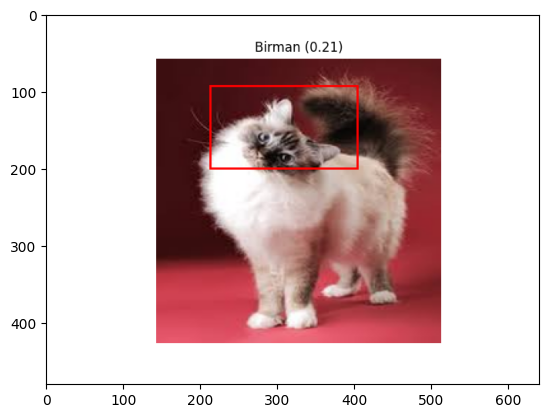

In [60]:
plt.imshow(bbox_img)

In [39]:
p= np.exp((a))/ np.sum(np.exp(a))

In [42]:
p

array([[0.00728972, 0.02767695, 0.00968852, 0.00654245, 0.01127248,
        0.00722799, 0.21268891, 0.01337588, 0.01528665, 0.01656496,
        0.02129028, 0.00639402, 0.01115294, 0.00518306, 0.00607893,
        0.01722957, 0.01371106, 0.02234239, 0.01275892, 0.01320331,
        0.01019384, 0.01016977, 0.00872406, 0.01527822, 0.01610053,
        0.03622878, 0.12013895, 0.01523966, 0.01244438, 0.01217803,
        0.00959297, 0.01038404, 0.20628133, 0.02176695, 0.00806457,
        0.01852436, 0.01173053]], dtype=float32)